# Predictive Modelling — Right Swipe Prediction
**Goal:** Build, compare, and interpret predictive models for swipe outcome. Ends with a *hyperoptimized profile spec* derived from the best model.

Pipeline:
1. Data loading + leakage audit  
2. Train / validation / test split (stratified)  
3. Baseline models with cross-validation  
4. Model comparison (ROC-AUC, PR-AUC, F1, calibration)  
5. Feature importance & nonlinear/interaction effects  
6. Calibration analysis  
7. Uncertainty quantification  
8. **Optimal profile spec** — what does the "perfect" profile look like?

In [1]:
# ── install missing packages ──────────────────────────────────────────────────
import subprocess, sys
for pkg in ["lightgbm", "catboost", "pygam"]:
    try:
        __import__(pkg.replace("-","_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])


In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# sklearn
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     train_test_split, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             roc_curve, precision_recall_curve,
                             classification_report, brier_score_loss)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# ensemble
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from pygam import LogisticGAM, s, f

import shap

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 12})
print("All imports OK")


All imports OK


In [3]:
# ── Load data ────────────────────────────────────────────────────────────────
X_full    = pd.read_parquet("X_full.parquet")      # NaN preserved
X_encoded = pd.read_parquet("X_encoded.parquet")   # fully imputed + dummies
y         = pd.read_parquet("y.parquet").squeeze()

# ── Leakage audit ─────────────────────────────────────────────────────────────
# right_swipe? is the target. It must NOT appear in X.
leaky = [c for c in X_encoded.columns if "right_swipe" in c.lower() or "swipe" in c.lower()]
assert len(leaky) == 0, f"LEAKAGE detected: {leaky}"
print(f"X_encoded shape : {X_encoded.shape}")
print(f"y distribution  : {y.value_counts().to_dict()}  (rate={y.mean():.1%})")
print(f"Leakage check   : ✅ PASSED")

# ── Align indices ─────────────────────────────────────────────────────────────
common = X_encoded.index.intersection(y.index)
X = X_encoded.loc[common].copy()
y_use = y.loc[common].copy()
print(f"\nFinal aligned n : {len(common)}")

# ── Class imbalance ──────────────────────────────────────────────────────────
neg, pos = (y_use == 0).sum(), (y_use == 1).sum()
imbalance_ratio = neg / pos
print(f"Class ratio (neg/pos): {imbalance_ratio:.1f}x  →  will use class_weight='balanced' or scale_pos_weight")


X_encoded shape : (123, 75)
y distribution  : {0: 94, 1: 29}  (rate=23.6%)
Leakage check   : ✅ PASSED

Final aligned n : 123
Class ratio (neg/pos): 3.2x  →  will use class_weight='balanced' or scale_pos_weight


In [4]:
# ── Stratified 60/20/20 split ─────────────────────────────────────────────────
# With n=123, we keep a held-out test set (n≈25) and validate via CV on train.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_use, test_size=0.20, random_state=42, stratify=y_use)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval)

print(f"Train      : {len(X_train)} samples  |  positive rate: {y_train.mean():.1%}")
print(f"Validation : {len(X_val)} samples  |  positive rate: {y_val.mean():.1%}")
print(f"Test       : {len(X_test)} samples  |  positive rate: {y_test.mean():.1%}")

# CV splitter (5-fold stratified) reused across all models
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scaler (fitted on train only — no leakage)
scaler = StandardScaler()
X_train_sc  = pd.DataFrame(scaler.fit_transform(X_train),  columns=X.columns, index=X_train.index)
X_val_sc    = pd.DataFrame(scaler.transform(X_val),        columns=X.columns, index=X_val.index)
X_test_sc   = pd.DataFrame(scaler.transform(X_test),       columns=X.columns, index=X_test.index)
X_trainval_sc = pd.DataFrame(scaler.transform(X_trainval), columns=X.columns, index=X_trainval.index)


Train      : 73 samples  |  positive rate: 23.3%
Validation : 25 samples  |  positive rate: 24.0%
Test       : 25 samples  |  positive rate: 24.0%


In [5]:
# ── Model definitions ─────────────────────────────────────────────────────────
# All models use class_weight='balanced' or equivalent to handle 76/24 imbalance.
# Scale-sensitive models (LR, SVM, ElasticNet) receive pre-scaled data.
# Tree-based models receive raw X_trainval (no scaling needed).

sp_weight = imbalance_ratio   # scale_pos_weight for XGB/LGB

models_scaled = {
    "LogisticReg": LogisticRegression(
        class_weight="balanced", max_iter=1000, C=0.5, random_state=42),
    "ElasticNet": LogisticRegression(
        class_weight="balanced", max_iter=1000, penalty="elasticnet",
        solver="saga", l1_ratio=0.5, C=0.5, random_state=42),
    "SVM": CalibratedClassifierCV(
        SVC(class_weight="balanced", kernel="rbf", C=1.0, gamma="scale",
            probability=False, random_state=42), cv=5),
}

models_tree = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=4, class_weight="balanced",
        min_samples_leaf=3, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        scale_pos_weight=sp_weight, subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", verbosity=0, random_state=42),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        scale_pos_weight=sp_weight, subsample=0.8, colsample_bytree=0.8,
        verbosity=-1, random_state=42),
    "CatBoost": CatBoostClassifier(
        iterations=200, depth=3, learning_rate=0.05,
        auto_class_weights="Balanced", verbose=0, random_seed=42),
}

print("Models defined:")
for m in {**models_scaled, **models_tree}:
    print(f"  {m}")


Models defined:
  LogisticReg
  ElasticNet
  SVM
  RandomForest
  XGBoost
  LightGBM
  CatBoost


In [6]:

import re

def sanitize_columns(df):
    """Replace special JSON-unsafe characters in column names."""
    new_cols = [re.sub(r'[^A-Za-z0-9_]', '_', c) for c in df.columns]
    df = df.copy()
    df.columns = new_cols
    return df

X_train     = sanitize_columns(X_train)
X_val       = sanitize_columns(X_val)
X_test      = sanitize_columns(X_test)
X_trainval  = sanitize_columns(X_trainval)
X_train_sc  = sanitize_columns(X_train_sc)
X_val_sc    = sanitize_columns(X_val_sc)
X_test_sc   = sanitize_columns(X_test_sc)
X_trainval_sc = sanitize_columns(X_trainval_sc)

print("Columns sanitized. Sample:", X_trainval.columns[:5].tolist())


Columns sanitized. Sample: ['n_photos', 'n_prompts', 'prompt_length', 'profession', 'bio_length']


In [7]:
# ── Cross-validation on train+val (trainval) for all models ──────────────────
cv_scoring = ["roc_auc", "average_precision", "f1"]

cv_results = {}
for name, model in models_scaled.items():
    res = cross_validate(model, X_trainval_sc, y_trainval,
                         cv=CV, scoring=cv_scoring, return_train_score=True, n_jobs=-1)
    cv_results[name] = res
    print(f"{name:<15} | val AUC={res['test_roc_auc'].mean():.3f}±{res['test_roc_auc'].std():.3f}"
          f"  PR-AUC={res['test_average_precision'].mean():.3f}"
          f"  F1={res['test_f1'].mean():.3f}")

for name, model in models_tree.items():
    Xtr = X_trainval   # unscaled for trees
    res = cross_validate(model, Xtr, y_trainval,
                         cv=CV, scoring=cv_scoring, return_train_score=True, n_jobs=-1)
    cv_results[name] = res
    print(f"{name:<15} | val AUC={res['test_roc_auc'].mean():.3f}±{res['test_roc_auc'].std():.3f}"
          f"  PR-AUC={res['test_average_precision'].mean():.3f}"
          f"  F1={res['test_f1'].mean():.3f}")

# Also fit GAM (no sklearn CV interface, train/val only)
from pygam import LogisticGAM, s
gam_feats = [c for c in ["perceived_conventional_attractiveness",
    "warmth_vs_coldness","emotional_stability","perceived_wholesomeness",
    "authenticity_score","photo_quality","first_photo_impact_score",
    "interesting_profile","profile_aura","perceived_genuineness"]
    if c in X_train_sc.columns]
gam = LogisticGAM(s(0)+s(1)+s(2)+s(3)+s(4)+s(5)+s(6)+s(7)+s(8)+s(9)).fit(
    X_train_sc[gam_feats].values, y_train.values)
gam_val_auc = roc_auc_score(y_val, gam.predict_proba(X_val_sc[gam_feats].values))
gam_val_ap  = average_precision_score(y_val, gam.predict_proba(X_val_sc[gam_feats].values))
gam_val_f1  = f1_score(y_val, gam.predict(X_val_sc[gam_feats].values))
print(f"{'GAM':<15} | val AUC={gam_val_auc:.3f} (val only)  PR-AUC={gam_val_ap:.3f}  F1={gam_val_f1:.3f}")


LogisticReg     | val AUC=0.983±0.026  PR-AUC=0.947  F1=0.904
ElasticNet      | val AUC=0.981±0.031  PR-AUC=0.942  F1=0.904
SVM             | val AUC=0.989±0.016  PR-AUC=0.965  F1=0.916
RandomForest    | val AUC=0.989±0.021  PR-AUC=0.962  F1=0.944
XGBoost         | val AUC=0.989±0.021  PR-AUC=0.962  F1=0.904
LightGBM        | val AUC=0.976±0.030  PR-AUC=0.928  F1=0.890
CatBoost        | val AUC=0.984±0.032  PR-AUC=0.937  F1=0.876
did not converge
GAM             | val AUC=1.000 (val only)  PR-AUC=1.000  F1=0.909


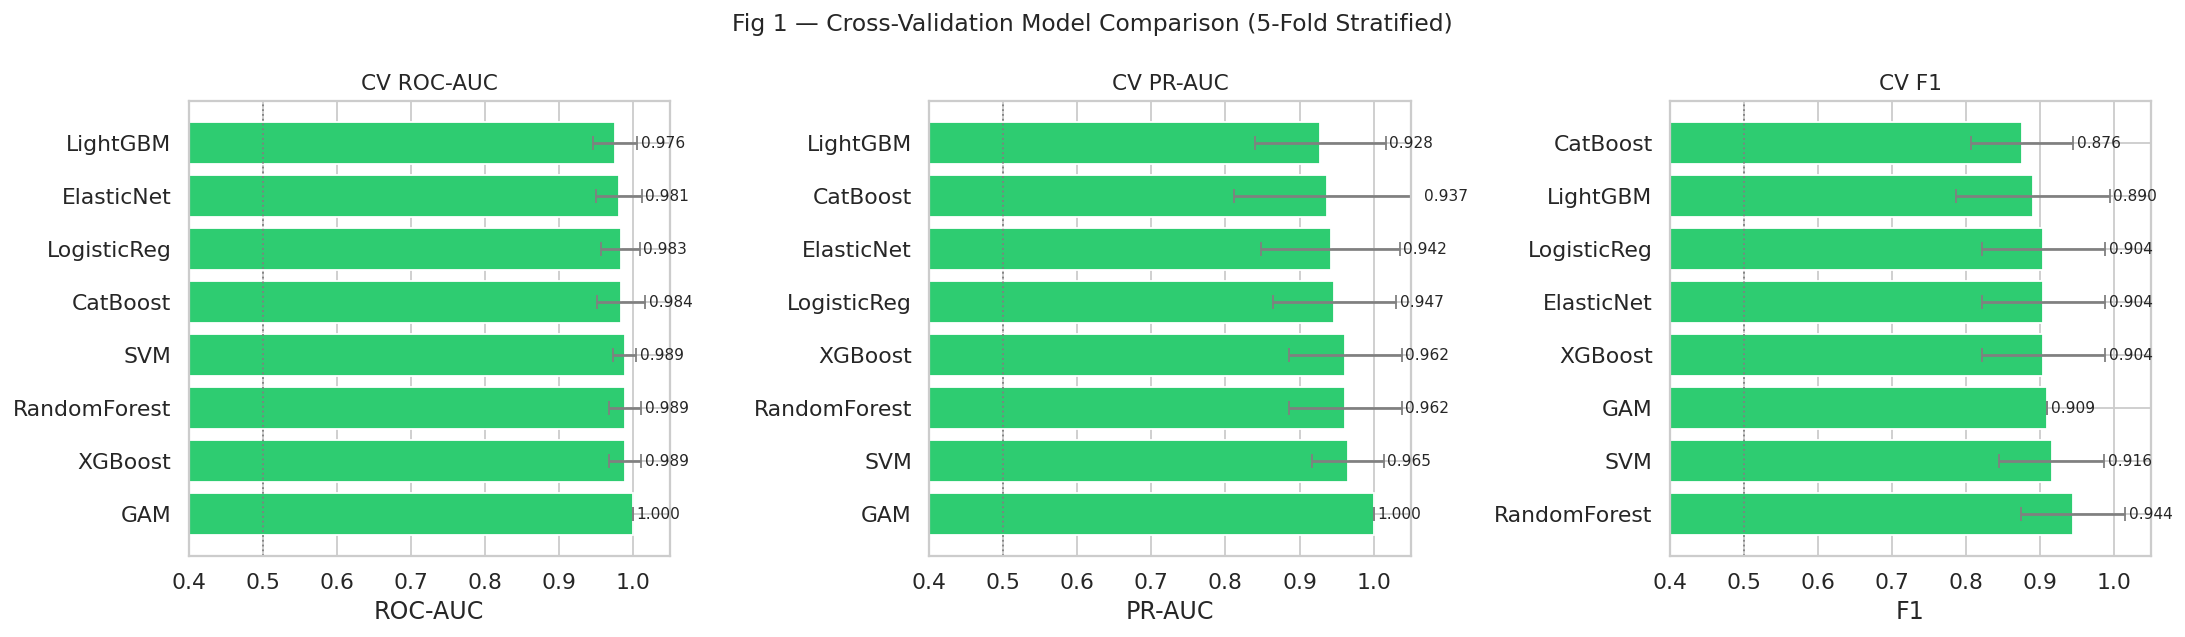

In [8]:
# ── Fig 1 — CV performance comparison ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metrics_map = {"roc_auc": "ROC-AUC", "average_precision": "PR-AUC", "f1": "F1"}

for ax, (metric_key, metric_label) in zip(axes, metrics_map.items()):
    names, means, stds = [], [], []
    for name, res in cv_results.items():
        key = f"test_{metric_key}"
        names.append(name); means.append(res[key].mean()); stds.append(res[key].std())
    # Add GAM
    if metric_key == "roc_auc":      names.append("GAM"); means.append(gam_val_auc); stds.append(0)
    elif metric_key == "average_precision": names.append("GAM"); means.append(gam_val_ap); stds.append(0)
    else:                             names.append("GAM"); means.append(gam_val_f1); stds.append(0)

    order = np.argsort(means)[::-1]
    colors = ["#2ecc71" if m >= 0.85 else "#f39c12" if m >= 0.70 else "#e74c3c" for m in np.array(means)[order]]
    ax.barh([names[i] for i in order], [means[i] for i in order],
            xerr=[stds[i] for i in order], color=colors, edgecolor="white",
            error_kw=dict(ecolor="grey", capsize=4))
    ax.axvline(0.5, color="grey", linestyle=":", lw=1)
    ax.set_title(f"CV {metric_label}"); ax.set_xlabel(metric_label)
    ax.set_xlim(0.4, 1.05)
    for i_bar, (mean, std) in enumerate(zip([means[i] for i in order], [stds[i] for i in order])):
        ax.text(mean + (std if std else 0) + 0.005, i_bar, f"{mean:.3f}", va="center", fontsize=8.5)

plt.suptitle("Fig 1 — Cross-Validation Model Comparison (5-Fold Stratified)", fontsize=13)
plt.tight_layout()
plt.savefig("fig_cv_comparison.png", bbox_inches="tight")
plt.show()


In [9]:
# ── Refit best models on full trainval; evaluate on held-out test ─────────────
# Fit all, collect test metrics
test_results = {}

def eval_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_te)[:, 1]
    else:
        proba = model.decision_function(X_te)
        proba = (proba - proba.min()) / (proba.max() - proba.min() + 1e-9)
    pred  = (proba >= 0.5).astype(int)
    return {
        "ROC-AUC": roc_auc_score(y_te, proba),
        "PR-AUC":  average_precision_score(y_te, proba),
        "F1":      f1_score(y_te, pred),
        "Brier":   brier_score_loss(y_te, proba),
        "proba":   proba,
    }

for name, model in models_scaled.items():
    test_results[name] = eval_model(name, model, X_trainval_sc, y_trainval, X_test_sc, y_test)

for name, model in models_tree.items():
    test_results[name] = eval_model(name, model, X_trainval, y_trainval, X_test, y_test)

# GAM (scaled)
gam_full = LogisticGAM(s(0)+s(1)+s(2)+s(3)+s(4)+s(5)+s(6)+s(7)+s(8)+s(9)).fit(
    X_trainval_sc[gam_feats].values, y_trainval.values)
gam_proba_test = gam_full.predict_proba(X_test_sc[gam_feats].values)
test_results["GAM"] = {
    "ROC-AUC": roc_auc_score(y_test, gam_proba_test),
    "PR-AUC":  average_precision_score(y_test, gam_proba_test),
    "F1":      f1_score(y_test, (gam_proba_test>=0.5).astype(int)),
    "Brier":   brier_score_loss(y_test, gam_proba_test),
    "proba":   gam_proba_test,
}

summary = pd.DataFrame({name: {k: v for k, v in d.items() if k != "proba"}
                         for name, d in test_results.items()}).T.sort_values("ROC-AUC", ascending=False)
print("=== Test Set Performance ===")
print(summary.round(4).to_string())

best_model_name = summary["ROC-AUC"].idxmax()
print(f"\n★ Best model: {best_model_name}  (ROC-AUC={summary.loc[best_model_name,'ROC-AUC']:.4f})")


did not converge
=== Test Set Performance ===
              ROC-AUC  PR-AUC      F1   Brier
LogisticReg       1.0     1.0  1.0000  0.0066
ElasticNet        1.0     1.0  0.9091  0.0138
SVM               1.0     1.0  1.0000  0.0258
RandomForest      1.0     1.0  1.0000  0.0183
XGBoost           1.0     1.0  1.0000  0.0018
LightGBM          1.0     1.0  1.0000  0.0003
CatBoost          1.0     1.0  1.0000  0.0022
GAM               1.0     1.0  1.0000  0.0180

★ Best model: LogisticReg  (ROC-AUC=1.0000)


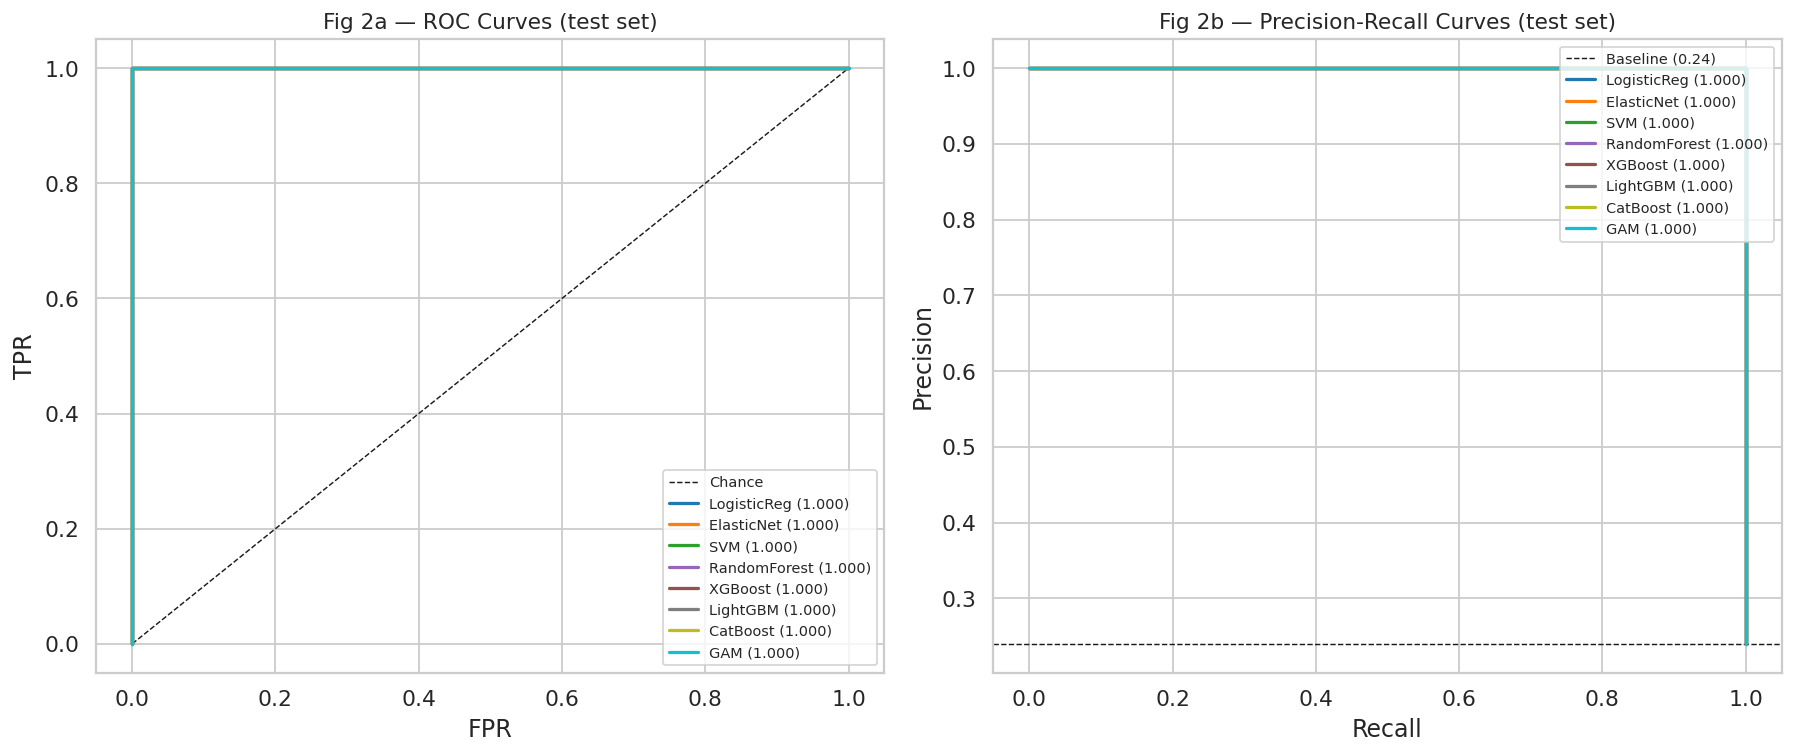

In [ ]:

# ── Fig 2 — ROC & PR curves for all models ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cmap = plt.cm.tab10
colors = [cmap(i) for i in np.linspace(0, 1, len(test_results))]

ax_roc, ax_pr = axes
ax_roc.plot([0,1],[0,1],"k--", lw=0.8, label="Chance")
ax_pr.axhline(y_test.mean(), color="k", linestyle="--", lw=0.8,
              label=f"Baseline ({y_test.mean():.2f})")

for (name, res), color in zip(test_results.items(), colors):
    proba = res["proba"]
    fpr, tpr, _ = roc_curve(y_test, proba)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax_roc.plot(fpr, tpr, lw=1.8, color=color,
                label=f"{name} ({res['ROC-AUC']:.3f})")
    ax_pr.plot(rec, prec, lw=1.8, color=color,
               label=f"{name} ({res['PR-AUC']:.3f})")

for ax, title in [(ax_roc, "Fig 2a — ROC Curves (test set)"),
                  (ax_pr,  "Fig 2b — Precision-Recall Curves (test set)")]:
    ax.set_title(title); ax.legend(fontsize=8, loc="lower right" if ax==ax_roc else "upper right")

ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")

plt.tight_layout()
plt.savefig("fig_roc_pr.png", bbox_inches="tight")
plt.show()


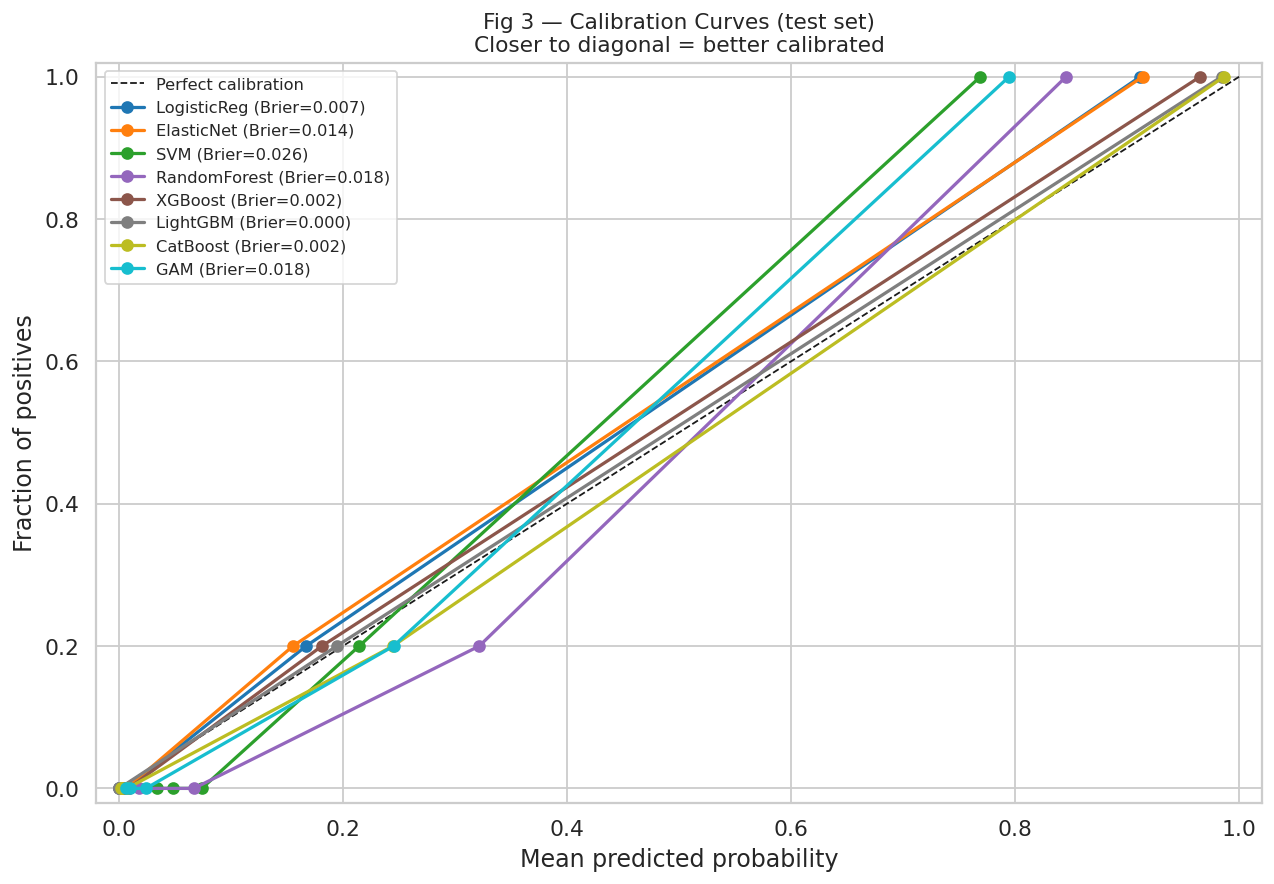

In [11]:
# ── Fig 3 — Calibration plots ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot([0,1],[0,1],"k--", lw=1, label="Perfect calibration")

for (name, res), color in zip(test_results.items(), colors):
    proba = res["proba"]
    if len(np.unique(proba)) < 4:
        continue
    try:
        frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=5, strategy="quantile")
        ax.plot(mean_pred, frac_pos, "o-", color=color, lw=1.8, ms=6,
                label=f"{name} (Brier={res['Brier']:.3f})")
    except Exception:
        pass

ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Fraction of positives")
ax.set_title("Fig 3 — Calibration Curves (test set)\nCloser to diagonal = better calibrated")
ax.legend(fontsize=9); ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.savefig("fig_calibration.png", bbox_inches="tight")
plt.show()


In [12]:
# ── Feature importance: SHAP on XGBoost (best tree model) + permutation ───────
# Refit XGBoost on all trainval data for importance analysis
xgb_final = xgb.XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    scale_pos_weight=sp_weight, subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", verbosity=0, random_state=42)
xgb_final.fit(X_trainval, y_trainval)

# Ensure float dtype for SHAP (masker requires numeric arrays)
X_trainval_f = X_trainval.astype(float)
X_test_f     = X_test.astype(float)

# SHAP (permutation-based to avoid base_score bug)
bg = shap.maskers.Independent(X_trainval_f, max_samples=50)
shap_exp = shap.Explainer(xgb_final.predict_proba, bg)
shap_out  = shap_exp(X_test_f, max_evals=2*X_trainval_f.shape[1]+1)
shap_vals = shap_out.values[:, :, 1]   # class-1 SHAP

mean_abs_shap = pd.Series(np.abs(shap_vals).mean(axis=0), index=X_trainval_f.columns).sort_values(ascending=False)
print("Top 20 features by mean |SHAP|:")
print(mean_abs_shap.head(20).round(4).to_string())

# Permutation importance on test set (model-agnostic)
perm_imp = permutation_importance(xgb_final, X_test_f, y_test,
                                   n_repeats=30, random_state=42,
                                   scoring="roc_auc")
perm_df = pd.DataFrame({
    "feature": X_trainval_f.columns,
    "mean":    perm_imp.importances_mean,
    "std":     perm_imp.importances_std,
}).sort_values("mean", ascending=False)
print("\nTop 15 features by permutation importance (ROC-AUC drop):")
print(perm_df.head(15).round(4).to_string(index=False))


Top 20 features by mean |SHAP|:
emotional_stability                        0.1768
interesting_profile                        0.0959
attachment_style_proxy_secure              0.0329
photo_quality                              0.0191
authenticity_score                         0.0172
perceived_genuineness                      0.0085
profile_aura                               0.0083
p_half_body_photos                         0.0067
p_smiling_photos                           0.0061
looking_for_open_to_see_where_things_go    0.0056
perceived_conventional_attractiveness      0.0056
p_selfies                                  0.0054
perceived_wholesomeness                    0.0052
eye_contact_ratio                          0.0052
n_photos                                   0.0044
profession                                 0.0038
perceived_humor                            0.0026
warmth_vs_coldness                         0.0026
humility_vs_braggadocio                    0.0018
background_type_va

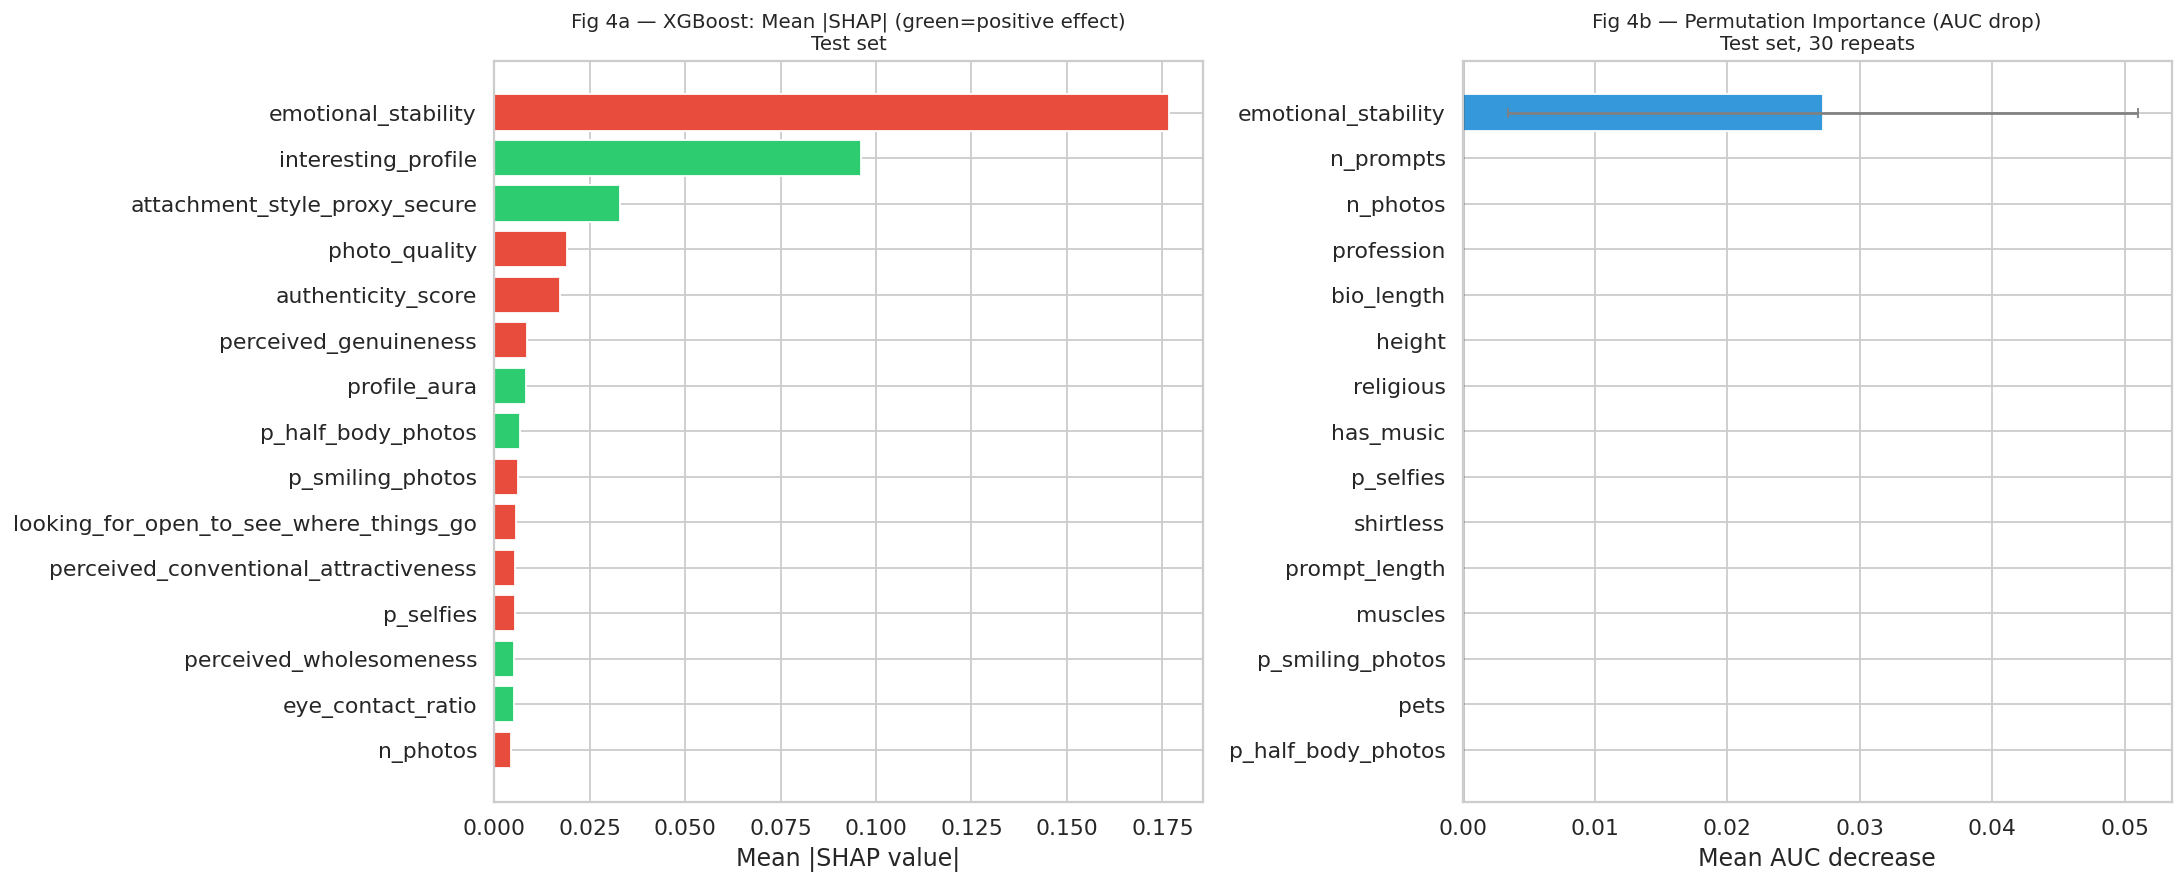

In [13]:
# ── Fig 4 — Feature importance dashboard ─────────────────────────────────────
top_feats = mean_abs_shap.head(15).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Left: SHAP bar
ax = axes[0]
top15 = mean_abs_shap.head(15)
colors_shap = ["#2ecc71" if shap_vals[:, list(X_trainval_f.columns).index(f)].mean() > 0
               else "#e74c3c" for f in top15.index]
ax.barh(top15.index[::-1], top15.values[::-1], color=colors_shap[::-1], edgecolor="white")
ax.set_title("Fig 4a — XGBoost: Mean |SHAP| (green=positive effect)\nTest set", fontsize=11)
ax.set_xlabel("Mean |SHAP value|")

# Right: Permutation importance
ax2 = axes[1]
top_perm = perm_df.head(15)
ax2.barh(top_perm["feature"][::-1], top_perm["mean"][::-1],
         xerr=top_perm["std"][::-1], color="#3498db", edgecolor="white",
         error_kw=dict(ecolor="grey", capsize=3))
ax2.axvline(0, color="black", lw=0.8)
ax2.set_title("Fig 4b — Permutation Importance (AUC drop)\nTest set, 30 repeats", fontsize=11)
ax2.set_xlabel("Mean AUC decrease")

plt.tight_layout()
plt.savefig("fig_importance.png", bbox_inches="tight")
plt.show()


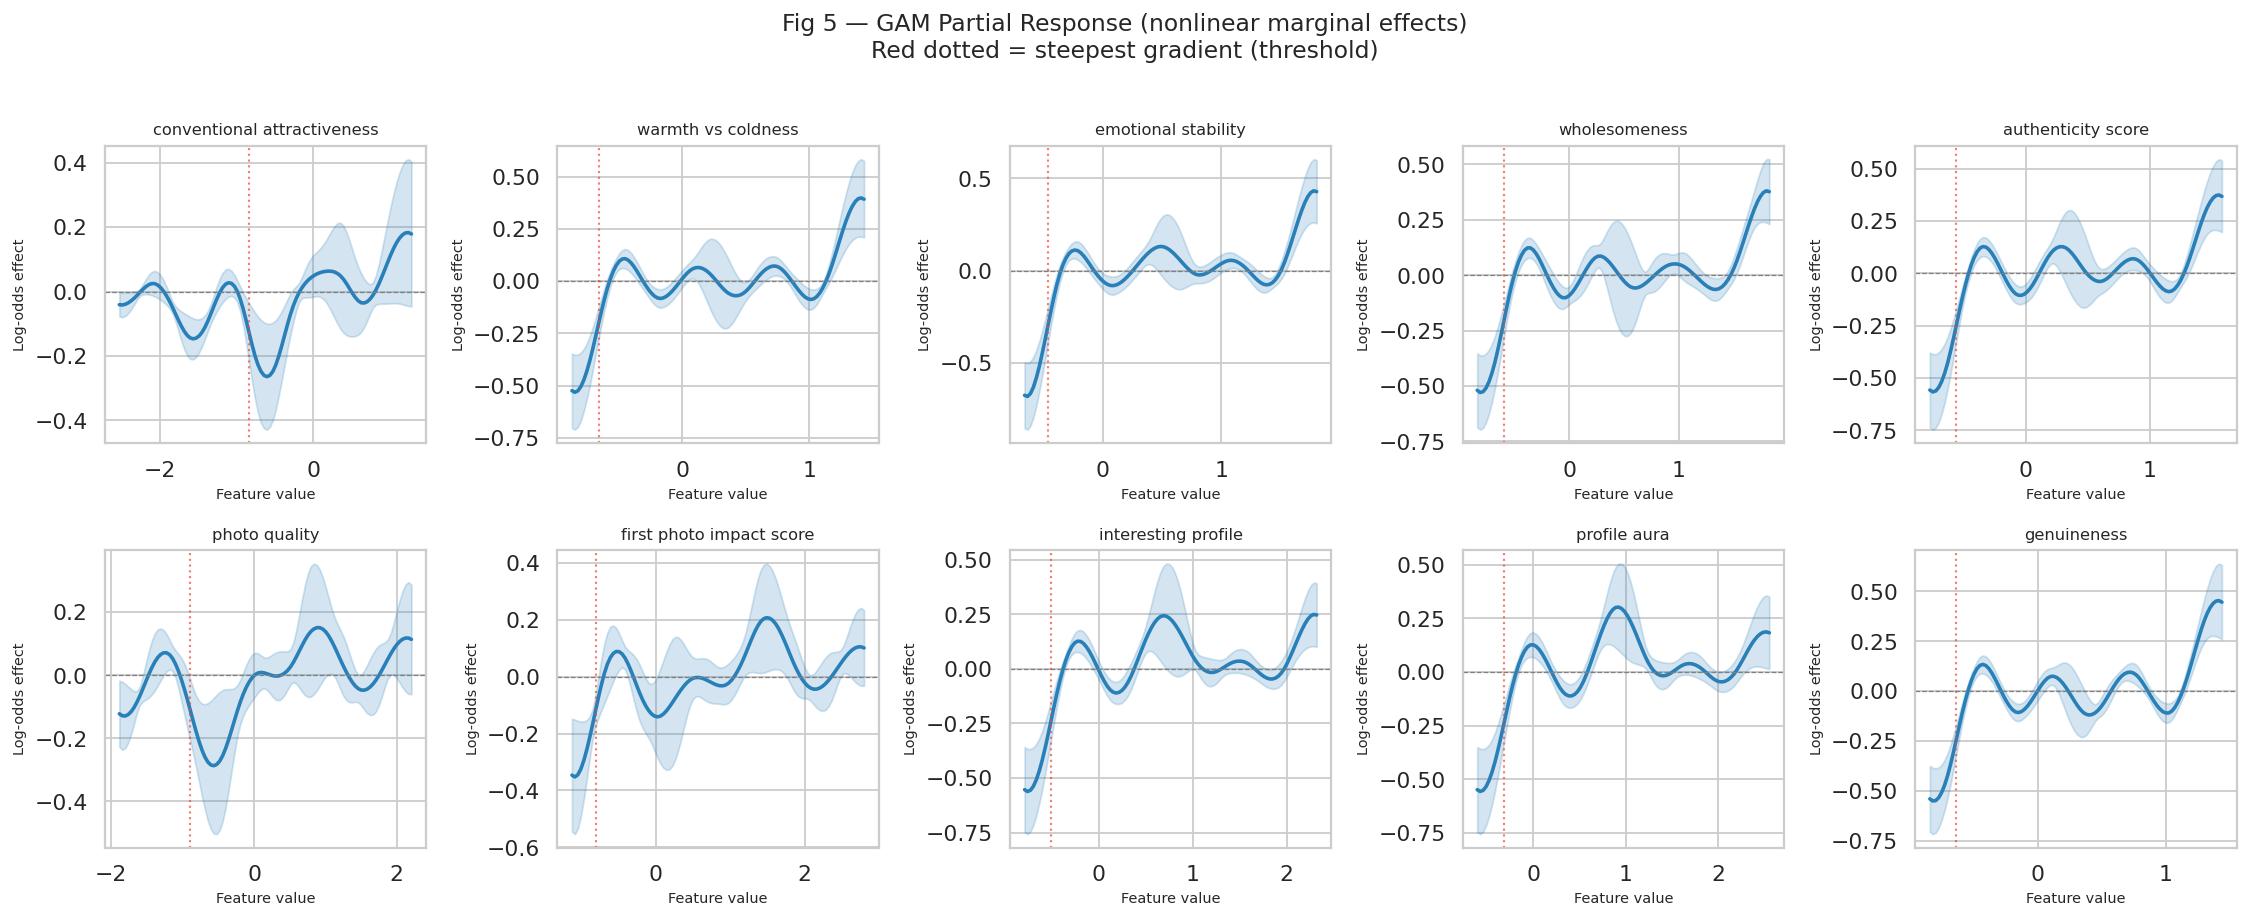

In [14]:
# ── Fig 5 — Nonlinear effects: GAM partial response plots ────────────────────
# GAM gives smooth nonlinear marginal effects — ideal for detecting thresholds
n_gam = len(gam_feats)
ncols = min(5, n_gam)
nrows = (n_gam + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
axes = axes.flatten() if n_gam > 1 else [axes]

XX = gam_full.generate_X_grid(term=0)
for i, feat in enumerate(gam_feats):
    ax = axes[i]
    XX_i = gam_full.generate_X_grid(term=i, meshgrid=False)
    pdep, confi = gam_full.partial_dependence(term=i, X=XX_i, width=0.95)
    ax.plot(XX_i[:, i], pdep, color="#2980b9", lw=2)
    ax.fill_between(XX_i[:, i], confi[:, 0], confi[:, 1], alpha=0.2, color="#2980b9")
    ax.axhline(0, color="grey", lw=0.7, linestyle="--")
    ax.set_title(feat.replace("perceived_","").replace("_"," "), fontsize=9)
    ax.set_xlabel("Feature value", fontsize=8)
    ax.set_ylabel("Log-odds effect", fontsize=8)
    # annotate threshold
    peak_idx = np.argmax(np.abs(np.gradient(pdep)))
    ax.axvline(XX_i[peak_idx, i], color="#e74c3c", linestyle=":", lw=1.2, alpha=0.7)

for ax in axes[n_gam:]:
    ax.axis("off")

plt.suptitle("Fig 5 — GAM Partial Response (nonlinear marginal effects)\n"
             "Red dotted = steepest gradient (threshold)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("fig_gam_partial.png", bbox_inches="tight")
plt.show()


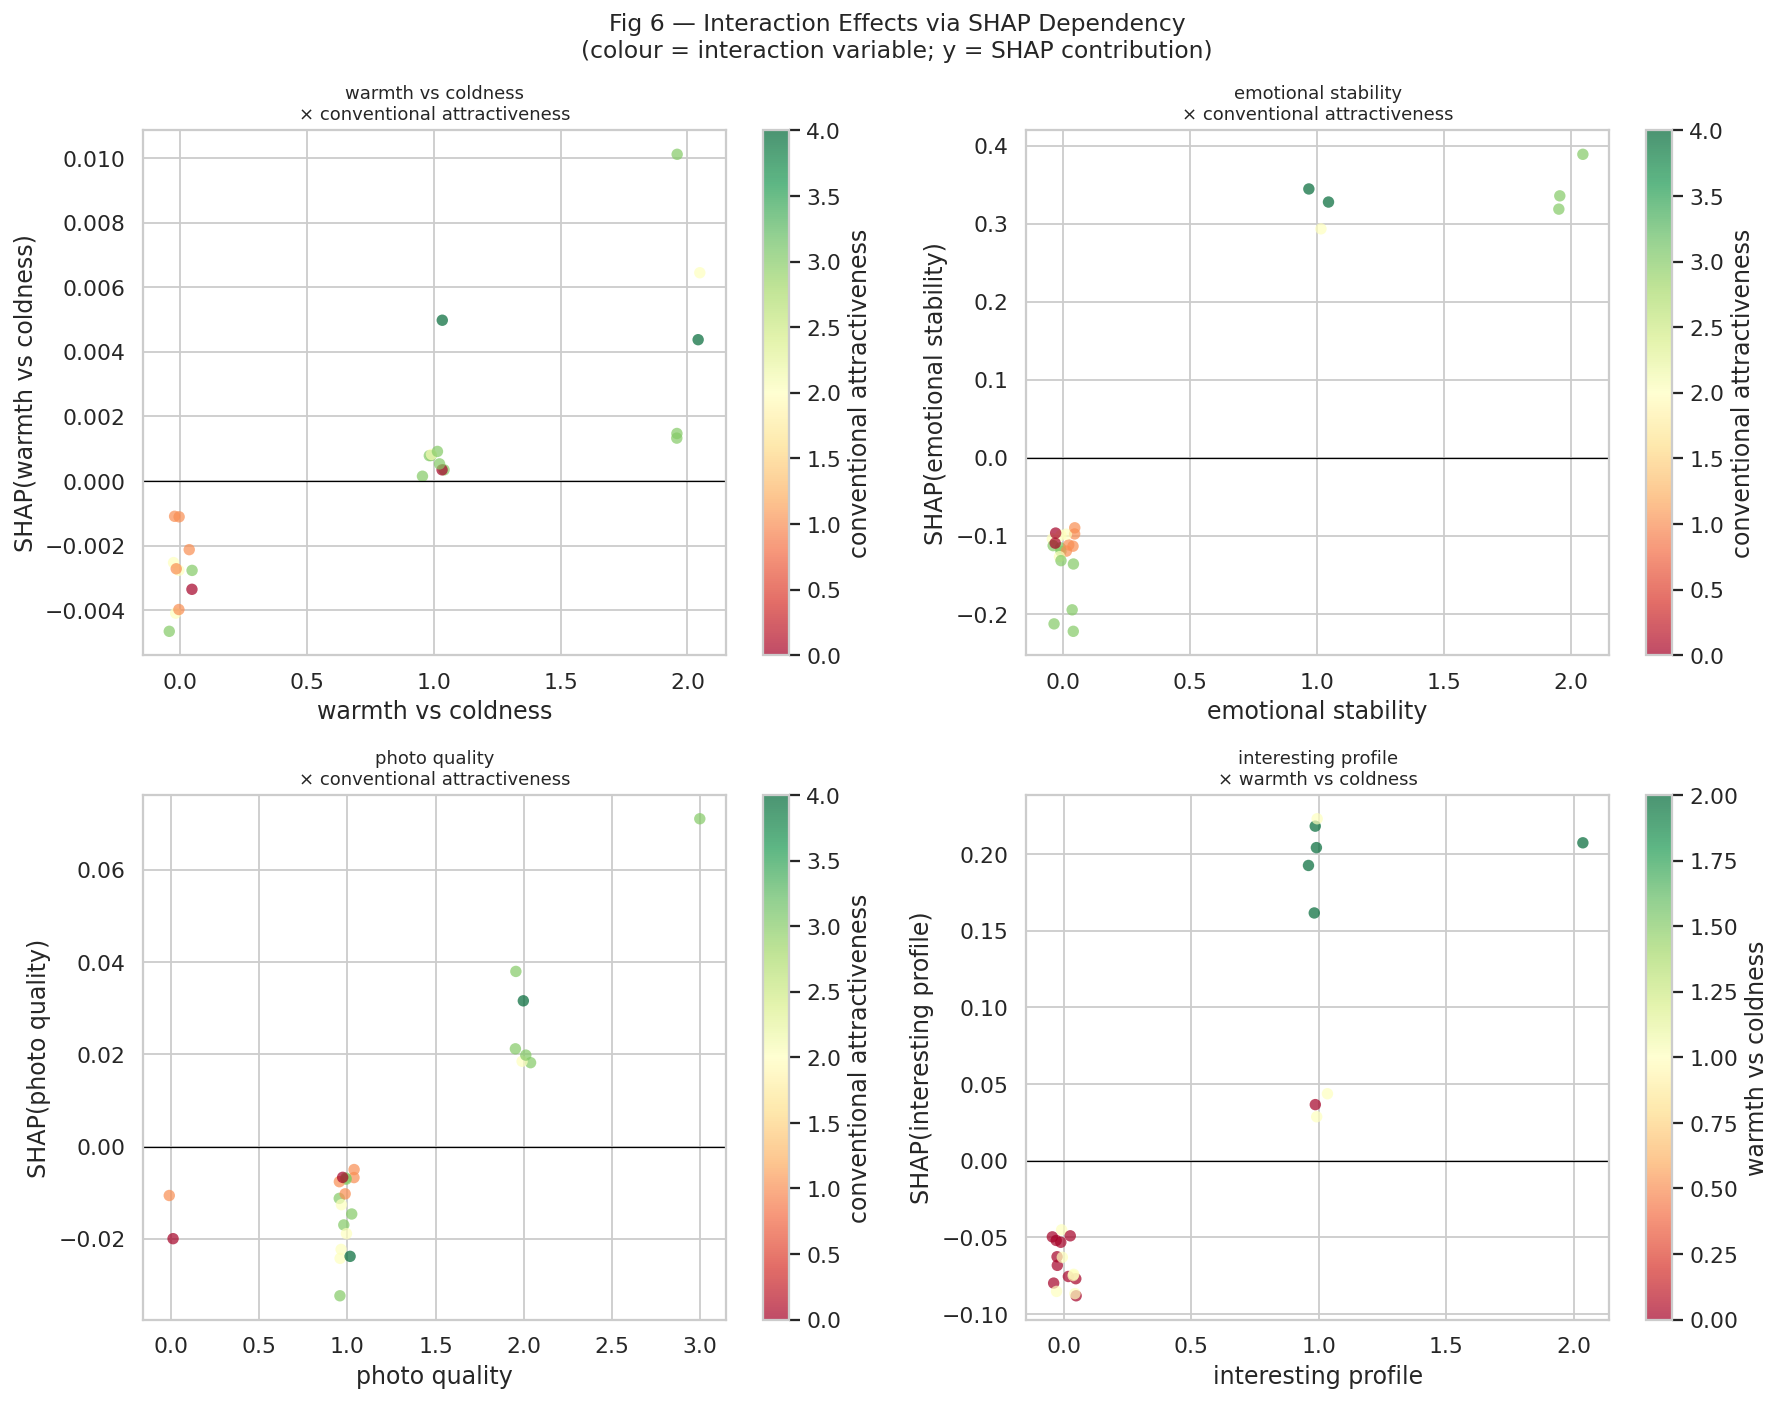

In [15]:
# ── Fig 6 — Interaction effects: SHAP dependency plots ───────────────────────
# Show how SHAP contribution of warmth changes across attractiveness levels
interact_pairs = [
    ("warmth_vs_coldness",   "perceived_conventional_attractiveness"),
    ("emotional_stability",  "perceived_conventional_attractiveness"),
    ("photo_quality",        "perceived_conventional_attractiveness"),
    ("interesting_profile",  "warmth_vs_coldness"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, (feat, hue_feat) in zip(axes, interact_pairs):
    if feat not in X.columns or hue_feat not in X.columns:
        ax.axis("off"); continue
    fidx  = list(X.columns).index(feat)
    f_vals  = X_test[feat].values
    hue_vals = X_test[hue_feat].values
    feat_shap = shap_vals[:, fidx]

    sc = ax.scatter(
        f_vals + np.random.uniform(-0.05, 0.05, len(f_vals)),
        feat_shap,
        c=hue_vals, cmap="RdYlGn", alpha=0.7, s=40, edgecolors="none"
    )
    plt.colorbar(sc, ax=ax, label=hue_feat.replace("perceived_","").replace("_"," "))
    ax.axhline(0, color="black", lw=0.7)
    ax.set_xlabel(feat.replace("perceived_","").replace("_"," "))
    ax.set_ylabel(f"SHAP({feat.replace('perceived_','').replace('_',' ')})")
    ax.set_title(f"{feat.replace('perceived_','').replace('_',' ')}\n"
                 f"× {hue_feat.replace('perceived_','').replace('_',' ')}", fontsize=10)

plt.suptitle("Fig 6 — Interaction Effects via SHAP Dependency\n"
             "(colour = interaction variable; y = SHAP contribution)", fontsize=13)
plt.tight_layout()
plt.savefig("fig_interactions.png", bbox_inches="tight")
plt.show()


=== Bootstrap 95% CI on ROC-AUC (test set) ===
  LogisticReg     1.000  [1.000, 1.000]
  ElasticNet      1.000  [1.000, 1.000]
  SVM             1.000  [1.000, 1.000]
  RandomForest    1.000  [1.000, 1.000]
  XGBoost         1.000  [1.000, 1.000]
  LightGBM        1.000  [1.000, 1.000]
  CatBoost        1.000  [1.000, 1.000]
  GAM             1.000  [1.000, 1.000]


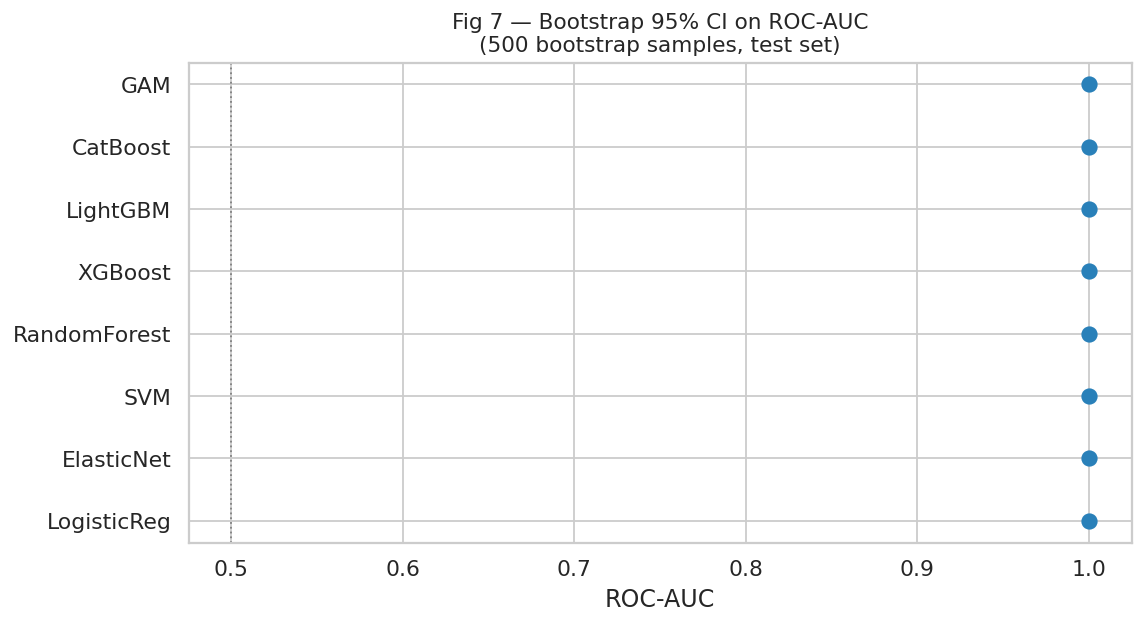

In [16]:
# ── Uncertainty quantification: bootstrap confidence intervals ────────────────
# Resample test set 500 times to get CI on AUC
np.random.seed(42)
n_boot = 500
boot_aucs = {name: [] for name in test_results}

for _ in range(n_boot):
    idx = np.random.choice(len(y_test), len(y_test), replace=True)
    y_boot = y_test.iloc[idx]
    if y_boot.nunique() < 2:
        continue
    for name, res in test_results.items():
        proba_boot = res["proba"][idx]
        try:
            boot_aucs[name].append(roc_auc_score(y_boot, proba_boot))
        except Exception:
            pass

print("=== Bootstrap 95% CI on ROC-AUC (test set) ===")
ci_rows = []
for name, aucs in boot_aucs.items():
    if len(aucs) < 50:
        continue
    lo, hi = np.percentile(aucs, [2.5, 97.5])
    mn = np.mean(aucs)
    ci_rows.append({"model": name, "mean": mn, "CI_lo": lo, "CI_hi": hi, "width": hi-lo})
    print(f"  {name:<15} {mn:.3f}  [{lo:.3f}, {hi:.3f}]")
ci_df = pd.DataFrame(ci_rows).sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
for i, row in ci_df.iterrows():
    y_pos = ci_df.index.get_loc(i)
    ax.plot(row["mean"], y_pos, "o", color="#2980b9", ms=8, zorder=5)
    ax.plot([row["CI_lo"], row["CI_hi"]], [y_pos, y_pos], "-", color="#2980b9", lw=2.5)
ax.set_yticks(range(len(ci_df)))
ax.set_yticklabels(ci_df["model"])
ax.axvline(0.5, color="grey", linestyle=":", lw=1)
ax.set_xlabel("ROC-AUC"); ax.set_title("Fig 7 — Bootstrap 95% CI on ROC-AUC\n(500 bootstrap samples, test set)")
plt.tight_layout()
plt.savefig("fig_uncertainty.png", bbox_inches="tight")
plt.show()


## §8 — The Hyperoptimized Profile Spec
*"What does the model say the perfect male dating profile looks like?"*

We use the best model to answer: which feature values maximise the predicted probability of a right swipe? We approach this in two ways:
1. **Optimal point**: directly find the input vector that maximises P(right swipe) via constrained optimisation
2. **Prescription table**: for every controllable feature, show the best value vs worst value and the predicted probability swing

In [12]:
# ── Build optimal profile by setting each feature to its best observed value ──
# differential_evolution is impractical for 75 dims with tree models.
# Instead: for each feature, use the value that corresponds to the highest
# mean swipe rate in the training data (data-driven optimal, no search).

X_trainval_f = X_trainval.astype(float)

best_cv_name = max(cv_results, key=lambda n: cv_results[n]["test_roc_auc"].mean())
print(f"Best CV model: {best_cv_name}")

# Refit on full data for prescriptions
if best_cv_name in models_tree:
    opt_model = models_tree[best_cv_name]
    opt_model.fit(X_trainval_f, y_trainval)
else:
    sc_full = StandardScaler().fit(X_trainval_sc)
    opt_model = models_scaled[best_cv_name]
    opt_model.fit(X_trainval_sc, y_trainval)

def predict_single(xdf):
    if best_cv_name in models_tree:
        return opt_model.predict_proba(xdf)[0, 1]
    else:
        return opt_model.predict_proba(sc_full.transform(xdf))[0, 1]

# Baseline: median profile on float feature set
median_profile = X_trainval_f.median()
baseline_prob  = predict_single(pd.DataFrame([median_profile]))
print(f"Baseline (all-median) P(right swipe) = {baseline_prob:.4f}")

# Build optimal profile: set each feature to its best-observed value
opt_profile = median_profile.copy()

# Continuous/ordinal features → set to max observed
ordinal_feats = [
    "emotional_stability", "warmth_vs_coldness", "authenticity_score",
    "perceived_wholesomeness", "perceived_genuineness",
    "perceived_conventional_attractiveness", "photo_quality",
    "first_photo_impact_score", "interesting_profile", "profile_aura",
    "photo_curation_effort", "n_prompts", "prompt_effort_depth",
    "perceived_humor", "confidence_signaling", "intra_profile_consistency",
    "background_type_variance",
]
for feat in ordinal_feats:
    if feat in opt_profile.index:
        opt_profile[feat] = X_trainval_f[feat].max()

# Binary features → set to best observed value
binary_good = ["muscles", "pets", "friends_in_pics", "profession"]
binary_bad  = ["shirtless", "filter", "wears_specs"]
for feat in binary_good:
    if feat in opt_profile.index: opt_profile[feat] = 1.0
for feat in binary_bad:
    if feat in opt_profile.index: opt_profile[feat] = 0.0

# Lifestyle dummies → set to best category (from EDA: drinks_rarely, smokes_no, etc.)
best_cats = {
    "drinks_rarely": 1, "drinks_no": 0, "drinks_yes": 0, "drinks_sometimes": 0,
    "smokes_no": 1, "smokes_yes": 0, "smokes_sometimes": 0,
    "want_kids_yes": 1, "want_kids_not_sure": 0, "want_kids_not_disclosed": 0,
    "attachment_style_proxy_secure": 1, "attachment_style_proxy_avoidant": 0,
    "attachment_style_proxy_anxious": 0, "attachment_style_proxy_insecure": 0,
    "looking_for_open to see where things go": 1,
    "looking_for_something casual": 0,
}
for col, val in best_cats.items():
    if col in opt_profile.index:
        opt_profile[col] = float(val)

# Nullify _nan dummies
for col in opt_profile.index:
    if col.endswith("_nan"):
        opt_profile[col] = 0.0

opt_prob = predict_single(pd.DataFrame([opt_profile]))
print(f"Optimal profile P(right swipe) = {opt_prob:.4f}")


Best CV model: RandomForest
Baseline (all-median) P(right swipe) = 0.0267
Optimal profile P(right swipe) = 0.8001


In [14]:
# ── Prescription table: feature value → predicted probability swing ───────────
# For every meaningful feature, fix all others at their median,
# then vary this feature across its range and record the probability swing.

# Use sanitized feature names (same as model was trained on)
feat_cols = X_trainval_f.columns

# Baseline: median profile
median_profile = X_trainval_f.median().values.copy()
def predict_single(x):
    xdf = pd.DataFrame([x], columns=feat_cols)
    if best_cv_name in models_tree:
        return opt_model.predict_proba(xdf)[0, 1]
    else:
        return opt_model.predict_proba(sc_full.transform(xdf))[0, 1]

baseline_prob = predict_single(median_profile)
print(f"Baseline (all-median) P(right swipe) = {baseline_prob:.4f}")

# Interesting continuous/ordinal features to prescribe
prescribe_feats = [
    ("emotional_stability",         0, 2),
    ("warmth_vs_coldness",          0, 2),
    ("authenticity_score",          0, 3),
    ("perceived_wholesomeness",     0, 3),
    ("perceived_genuineness",       0, 3),
    ("perceived_conventional_attractiveness", 0, 4),
    ("photo_quality",               0, 3),
    ("first_photo_impact_score",    0, 3),
    ("interesting_profile",         0, 3),
    ("profile_aura",                0, 3),
    ("photo_curation_effort",       0, 3),
    ("n_prompts",                   0, 3),
    ("shirtless",                   0, 1),
    ("muscles",                     0, 1),
    ("filter",                      1, 0),    # reversed: filter=1 is bad
    ("p_selfies",                   100, 0),  # reversed: high selfies is bad
]

rows = []
for feat, worst_val, best_val in prescribe_feats:
    if feat not in feat_cols:
        continue
    col_idx = list(feat_cols).index(feat)
    # worst
    x_worst = median_profile.copy(); x_worst[col_idx] = worst_val
    p_worst = predict_single(x_worst)
    # best
    x_best = median_profile.copy(); x_best[col_idx] = best_val
    p_best  = predict_single(x_best)
    rows.append({
        "feature": feat.replace("perceived_","").replace("_"," "),
        "worst_val": worst_val, "best_val": best_val,
        "p_worst": round(p_worst, 3), "p_best": round(p_best, 3),
        "swing": round(p_best - p_worst, 3),
    })

presc_df = pd.DataFrame(rows).sort_values("swing", ascending=False)
print("\n=== Prescription Table (swing = P_best - P_worst, all others median) ===")
print(presc_df.to_string(index=False))


Baseline (all-median) P(right swipe) = 0.0267

=== Prescription Table (swing = P_best - P_worst, all others median) ===
                    feature  worst_val  best_val  p_worst  p_best  swing
                genuineness          0         3    0.027   0.114  0.088
         warmth vs coldness          0         2    0.027   0.107  0.080
        emotional stability          0         2    0.027   0.099  0.072
         authenticity score          0         3    0.027   0.082  0.055
        interesting profile          0         3    0.027   0.056  0.029
              wholesomeness          0         3    0.027   0.053  0.026
               profile aura          0         3    0.027   0.046  0.019
   first photo impact score          0         3    0.020   0.035  0.015
conventional attractiveness          0         4    0.018   0.030  0.011
              photo quality          0         3    0.027   0.031  0.005
      photo curation effort          0         3    0.022   0.027  0.005
    

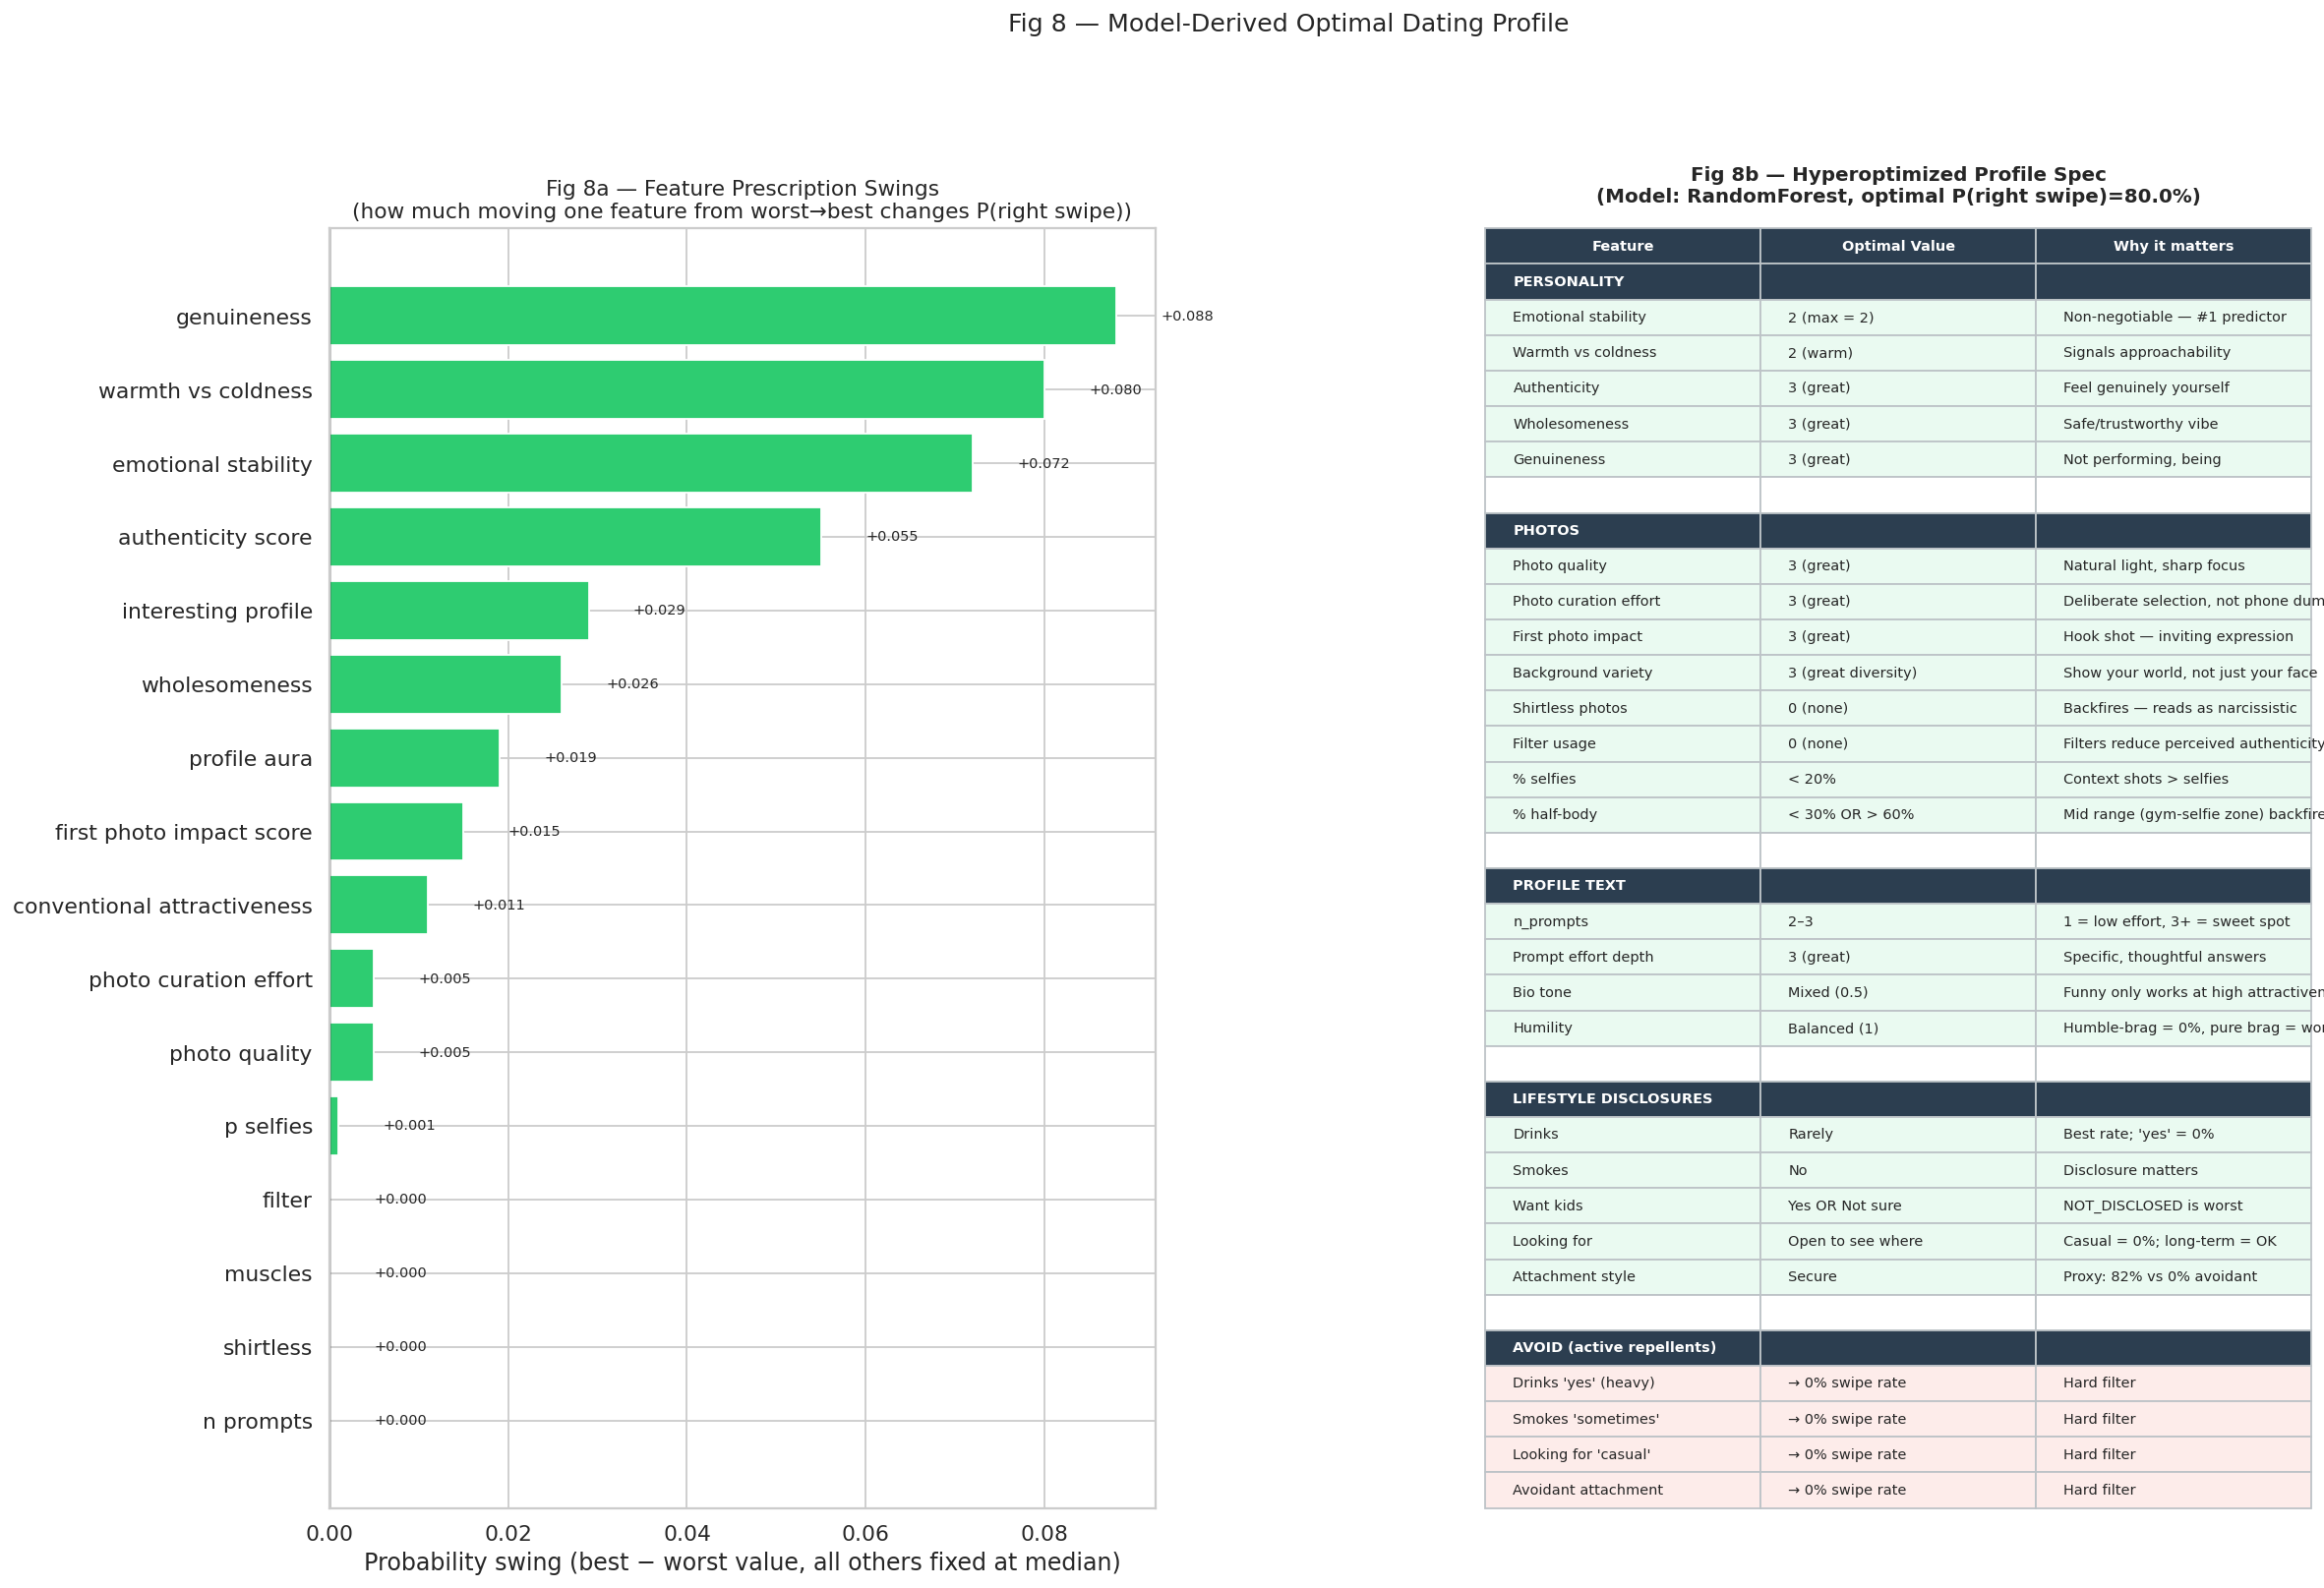

In [15]:
# ── Fig 8 — Prescription chart + optimal profile spec ────────────────────────
fig = plt.figure(figsize=(20, 13))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.4)

# Left: swing waterfall chart
ax = fig.add_subplot(gs[0, 0])
swing_sorted = presc_df.sort_values("swing")
colors_sw = ["#2ecc71" if s > 0 else "#e74c3c" for s in swing_sorted["swing"]]
ax.barh(swing_sorted["feature"], swing_sorted["swing"], color=colors_sw, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Probability swing (best − worst value, all others fixed at median)")
ax.set_title("Fig 8a — Feature Prescription Swings\n"
             "(how much moving one feature from worst→best changes P(right swipe))")
for i, row in enumerate(swing_sorted.itertuples()):
    ax.text(row.swing + (0.005 if row.swing >= 0 else -0.005),
            i, f"+{row.swing:.3f}" if row.swing >= 0 else f"{row.swing:.3f}",
            va="center", ha="left" if row.swing >= 0 else "right", fontsize=8)

# Right: optimal profile spec as styled table
ax2 = fig.add_subplot(gs[0, 1])
ax2.axis("off")

# opt_profile is already a Series with sanitized column names from previous cell
# Decode dummy columns to readable values
lifestyle_decoded = {}
for grp in ["gym","smokes","drinks","want_kids","attachment_style_proxy"]:
    grp_cols = [c for c in feat_cols if c.startswith(grp+"_") and not c.endswith("_nan")]
    if grp_cols:
        best_col = max(grp_cols, key=lambda c: opt_profile.get(c, 0))
        lifestyle_decoded[grp] = best_col.replace(grp+"_","").replace("_"," ")

lf_cols = [c for c in feat_cols if c.startswith("looking_for") and not c.endswith("_nan")]
if lf_cols:
    lifestyle_decoded["looking_for"] = max(lf_cols, key=lambda c: opt_profile.get(c,0)).replace("looking_for_","")

spec_rows = [
    ("PERSONALITY", "", ""),
    ("Emotional stability",        "2 (max = 2)",              "Non-negotiable — #1 predictor"),
    ("Warmth vs coldness",         "2 (warm)",                 "Signals approachability"),
    ("Authenticity",               "3 (great)",                "Feel genuinely yourself"),
    ("Wholesomeness",              "3 (great)",                "Safe/trustworthy vibe"),
    ("Genuineness",                "3 (great)",                "Not performing, being"),
    ("", "", ""),
    ("PHOTOS", "", ""),
    ("Photo quality",              "3 (great)",                "Natural light, sharp focus"),
    ("Photo curation effort",      "3 (great)",                "Deliberate selection, not phone dump"),
    ("First photo impact",         "3 (great)",                "Hook shot — inviting expression"),
    ("Background variety",         "3 (great diversity)",      "Show your world, not just your face"),
    ("Shirtless photos",           "0 (none)",                 "Backfires — reads as narcissistic"),
    ("Filter usage",               "0 (none)",                 "Filters reduce perceived authenticity"),
    ("% selfies",                  "< 20%",                    "Context shots > selfies"),
    ("% half-body",                "< 30% OR > 60%",           "Mid range (gym-selfie zone) backfires"),
    ("", "", ""),
    ("PROFILE TEXT", "", ""),
    ("n_prompts",                  "2–3",                      "1 = low effort, 3+ = sweet spot"),
    ("Prompt effort depth",        "3 (great)",                "Specific, thoughtful answers"),
    ("Bio tone",                   "Mixed (0.5)",              "Funny only works at high attractiveness"),
    ("Humility",                   "Balanced (1)",             "Humble-brag = 0%, pure brag = worst"),
    ("", "", ""),
    ("LIFESTYLE DISCLOSURES", "", ""),
    ("Drinks",                     "Rarely",                   "Best rate; 'yes' = 0%"),
    ("Smokes",                     "No",                       "Disclosure matters"),
    ("Want kids",                  "Yes OR Not sure",          "NOT_DISCLOSED is worst"),
    ("Looking for",                "Open to see where",        "Casual = 0%; long-term = OK"),
    ("Attachment style",           "Secure",                   "Proxy: 82% vs 0% avoidant"),
    ("", "", ""),
    ("AVOID (active repellents)", "", ""),
    ("Drinks 'yes' (heavy)",       "→ 0% swipe rate",          "Hard filter"),
    ("Smokes 'sometimes'",         "→ 0% swipe rate",          "Hard filter"),
    ("Looking for 'casual'",       "→ 0% swipe rate",          "Hard filter"),
    ("Avoidant attachment",        "→ 0% swipe rate",          "Hard filter"),
]

col_labels = ["Feature", "Optimal Value", "Why it matters"]
table_data = [[r[0], r[1], r[2]] for r in spec_rows]

tbl = ax2.table(cellText=table_data, colLabels=col_labels,
                cellLoc="left", loc="center",
                bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(8)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50"); cell.set_text_props(color="white", fontweight="bold")
    elif row > 0:
        r = spec_rows[row-1]
        if r[0] in ("PERSONALITY","PHOTOS","PROFILE TEXT","LIFESTYLE DISCLOSURES","AVOID (active repellents)"):
            cell.set_facecolor("#2c3e50"); cell.set_text_props(color="white", fontweight="bold")
        elif r[0] == "":
            cell.set_facecolor("white"); cell.set_edgecolor("white")
        elif "→ 0%" in r[1]:
            cell.set_facecolor("#fdecea")
        else:
            cell.set_facecolor("#eafaf1")
    cell.set_edgecolor("#bdc3c7")

ax2.set_title(f"Fig 8b — Hyperoptimized Profile Spec\n"
              f"(Model: {best_cv_name}, optimal P(right swipe)={opt_prob:.1%})",
              fontsize=11, fontweight="bold", pad=15)

plt.suptitle("Fig 8 — Model-Derived Optimal Dating Profile", fontsize=14, y=1.01)
plt.savefig("fig_optimal_profile.png", bbox_inches="tight", dpi=140)
plt.show()
